In [1]:
import os
import sys
import yaml
import tensorflow as tf
import keras
from keras import layers


# import utils functions auto-reload
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath('../src'))

from utils import *

from tensorflow.keras.applications import EfficientNetB5

# Load config (relative to notebooks/)
with open('../config.yml', 'r') as f:
    config = yaml.safe_load(f)

SEED = config['seed']
set_seeds(SEED)

I0000 00:00:1776596932.810191   73034 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
IMG_SIZE = (512, 512)
BATCH_SIZE = 4
NUM_CLASSES = config['num_classes']

# All paths relative to notebooks/
train_dir = config['paths']['train_dir']
val_dir   = config['paths']['val_dir']
test_dir  = config['paths']['test_dir']

train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)

Found 9282 files belonging to 23 classes.


W0000 00:00:1776596934.797765   73034 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776596934.804826   73034 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776596934.907910   73034 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5286 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:2b:00.0, compute capability: 12.0a


Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [3]:
# --- Data Augmentation ---
data_augmentation = build_standard_augmentation()

# --- Build Model ---
base_model = EfficientNetB5(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # freeze backbone for phase 1

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)     # training=False keeps BN layers in inference mode while frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)     # stabilise pooled features before dense layers
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="efficientnetb5_transfer")
model.summary()

Model: "efficientnetb5_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb5 (Functional)     │ (None, 16, 16, 2048)   │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,708,046 (113.33 MB)

 Trainable params: 1,190,423 (4.54 MB)

 Non-trainable params: 28,517,623 (108.79 MB)

In [4]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4, weight_decay=1e-4, gradient_accumulation_steps=32),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

In [5]:
# --- Train (Phase 1) ---
# 3e-4 instead of 1e-3 - mudei a LR, recomendacao do bestie
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

checkpoint_path = config['models']['efficientnetb5']['checkpoint']
callbacks = build_standard_callbacks(
    checkpoint_path=checkpoint_path,
)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
)

Epoch 1/20


I0000 00:00:1776596950.429174   73124 cuda_dnn.cc:461] Loaded cuDNN version 92000


2321/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2602 - f1_macro: 0.2197 - loss: 2.6997
Epoch 1: val_loss improved from None to 1.49721, saving model to ../models/efficientnetb5_best.keras

Epoch 1: finished saving model to ../models/efficientnetb5_best.keras
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 252s 103ms/step - accuracy: 0.3424 - f1_macro: 0.2980 - loss: 2.3246 - val_accuracy: 0.5667 - val_f1_macro: 0.5076 - val_loss: 1.4972 - learning_rate: 3.0000e-04
Epoch 2/20
2320/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4521 - f1_macro: 0.4143 - loss: 1.8884
Epoch 2: val_loss improved from 1.49721 to 1.31310, saving model to ../models/efficientnetb5_best.keras

Epoch 2: finished saving model to ../models/efficientnetb5_best.keras
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 236s 102ms/step - accuracy: 0.4719 - f1_macro: 0.4337 - loss: 1.8146 - val_accuracy: 0.6333 - val_f1_macro: 0.5860 - val_loss: 1.3131 - learning_rate: 3.0000e-04
Epoch 3/20
2320/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accur

In [ ]:
# --- Phase 2: Fine-tuning ---

# Unfreeze the last ~50 layers of EfficientNetB5.
# EfficientNet blocks are deeper than ResNet, so more layers must be unfrozen
# to expose the compound-scaled feature extractors to task-specific gradients.
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Very low LR to avoid disrupting pretrained weights
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

checkpoint_path = config['models']['efficientnetb5']['checkpoint']
callbacks = build_standard_callbacks(
    checkpoint_path=checkpoint_path,
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
)

Epoch 1/30


E0000 00:00:1776601680.596560   73034 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb5_transfer_1/efficientnetb5_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


2321/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5647 - f1_macro: 0.5398 - loss: 1.4587
Epoch 1: val_loss improved from None to 1.21874, saving model to ../models/efficientnetb3_best.keras

Epoch 1: finished saving model to ../models/efficientnetb3_best.keras
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 287s 118ms/step - accuracy: 0.5974 - f1_macro: 0.5755 - loss: 1.3651 - val_accuracy: 0.6626 - val_f1_macro: 0.6347 - val_loss: 1.2187 - learning_rate: 1.0000e-05
Epoch 2/30
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6361 - f1_macro: 0.6148 - loss: 1.2323 
Epoch 2: val_loss improved from 1.21874 to 1.14933, saving model to ../models/efficientnetb3_best.keras

Epoch 2: finished saving model to ../models/efficientnetb3_best.keras
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 271s 117ms/step - accuracy: 0.6515 - f1_macro: 0.6313 - loss: 1.1857 - val_accuracy: 0.6869 - val_f1_macro: 0.6623 - val_loss: 1.1493 - learning_rate: 1.0000e-05
Epoch 3/30
2321/2321 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accu

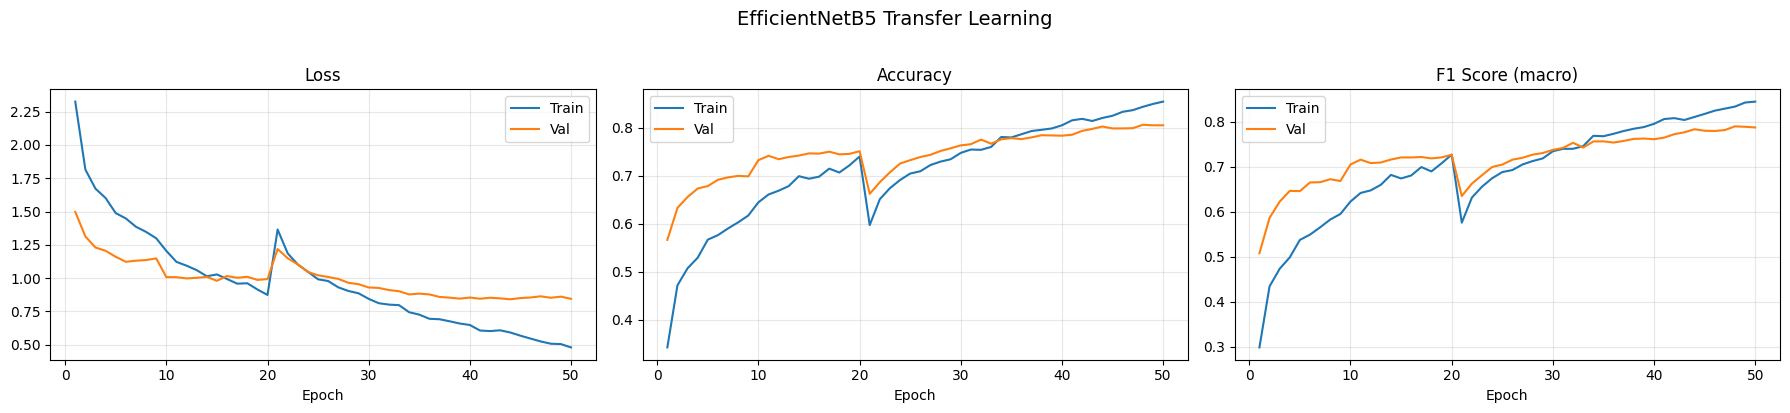

Best epoch (lowest val_loss): 44
  Val Loss: 0.8415
  Val Acc:  0.8030
  Val F1:   0.7833


In [7]:
plot_learning_curves([history_phase1, history_phase2], title="EfficientNetB5 Transfer Learning")


  EfficientNetB5 Transfer Learning - Test Evaluation
  Test Loss:     0.7956
  Test Accuracy: 0.7898
  Test F1 Macro: 0.7693

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.94      0.85      0.89        87
      Boris_Kustodiev       0.68      0.67      0.68        67
     Camille_Pissarro       0.70      0.78      0.74        93
        Childe_Hassam       0.68      0.59      0.63        58
         Claude_Monet       0.85      0.74      0.80       141
          Edgar_Degas       0.77      0.74      0.76        65
        Eugene_Boudin       0.68      0.88      0.77        59
         Gustave_Dore       0.92      0.95      0.93        80
           Ilya_Repin       0.61      0.64      0.62        58
      Ivan_Aivazovsky       0.89      0.90      0.89        61
        Ivan_Shishkin       0.76      0.85      0.80        55
  John_Singer_Sargent       0.66      0.80      0.72        83
         Marc_Chagall       0.

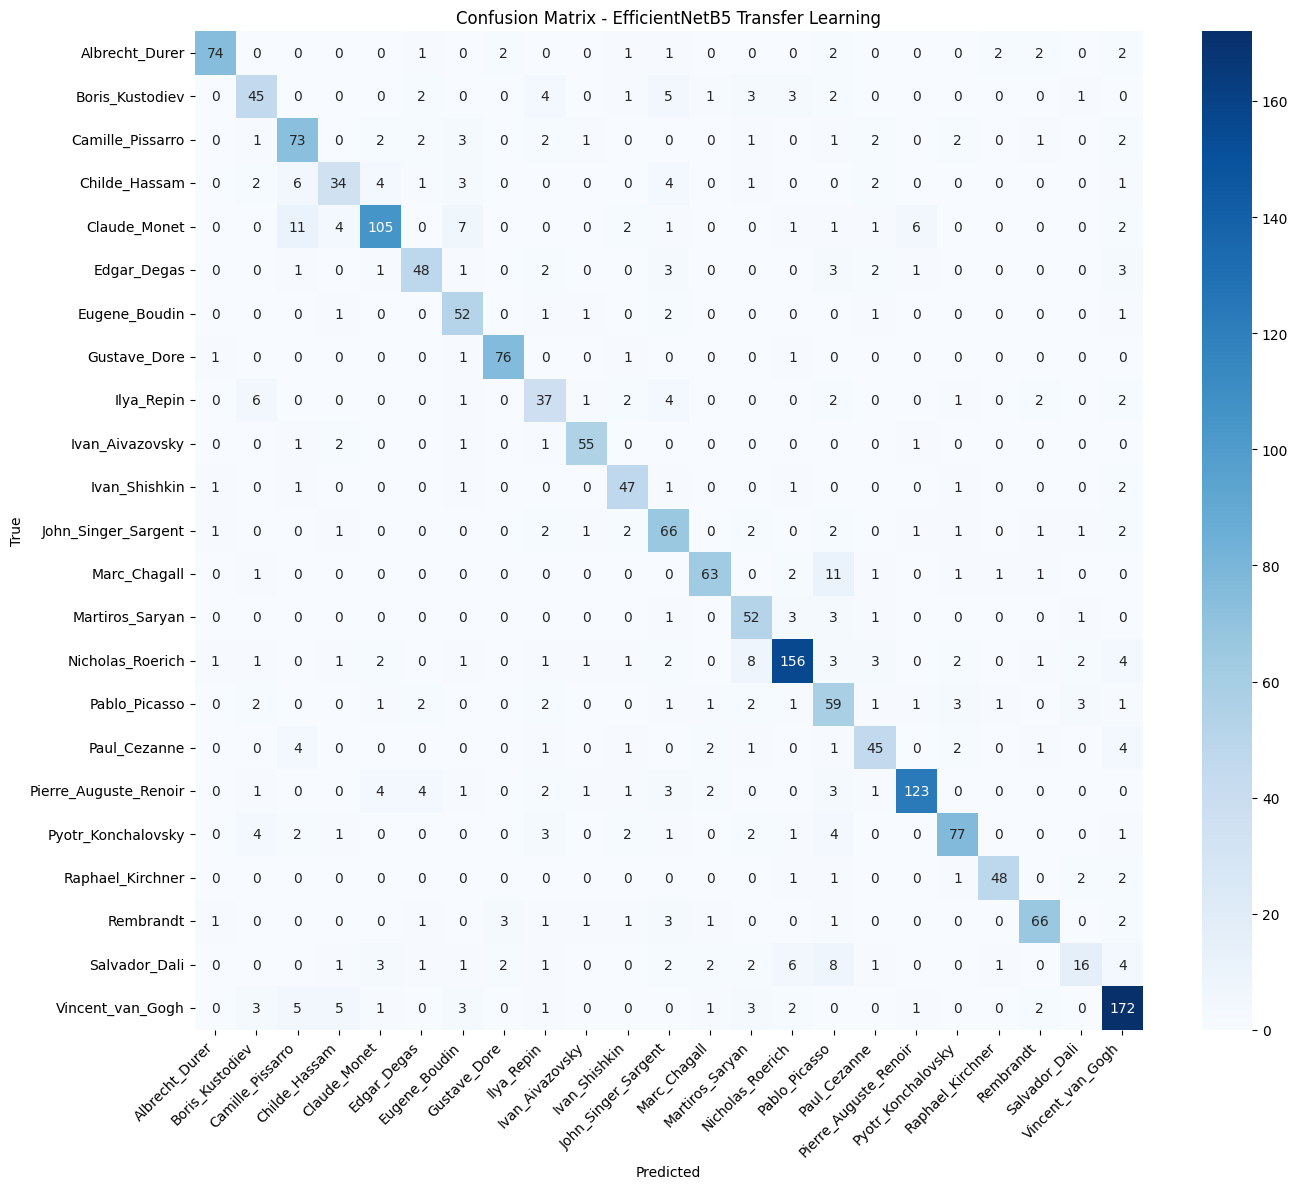

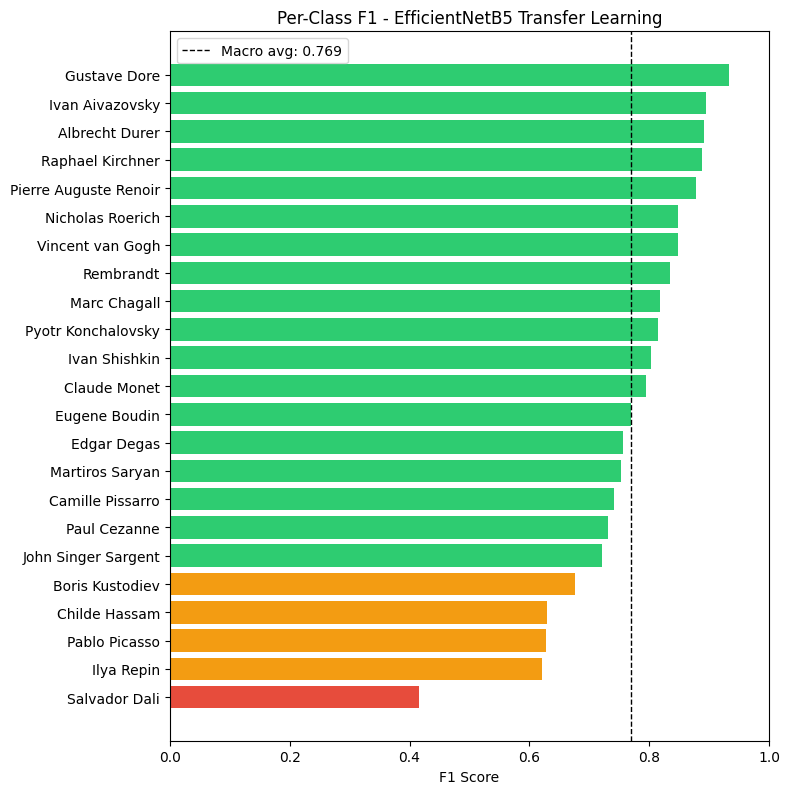

In [8]:
metrics_efficientnet = evaluate_model(model, test_ds, class_names, "EfficientNetB5 Transfer Learning")

In [9]:
save_history([history_phase1, history_phase2], config['models']['efficientnetb5']['history'])

History saved to ../models/efficientnetb5_history.json
